In [51]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from textblob import TextBlob
from wordcloud import WordCloud
from collections import Counter

# Download required NLTK resources
nltk.download('stopwords')

from nltk.corpus import stopwords

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)

print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [52]:
# Load the dataset
df = pd.read_csv('/content/chatgpt_reviews.csv')

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 196,727
Columns: 4


In [53]:
#viewing first 5 rows
df.head()

,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to anything, it gives me tips, in gaming, studies, and life, etc. This app is also helpful if you were having problems in things! also there are some pr...",5,2024-08-23 19:20:39


In [54]:
#standerdizing column name
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
    )
#viewing the data set with edited column_name
df.head()

,review_id,review,ratings,review_date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to anything, it gives me tips, in gaming, studies, and life, etc. This app is also helpful if you were having problems in things! also there are some pr...",5,2024-08-23 19:20:39


In [55]:
#Checking data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196727 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   review_id    196727 non-null  object
 1   review       196721 non-null  object
 2   ratings      196727 non-null  int64 
 3   review_date  196727 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.0+ MB


In [56]:
#finding count of null value
df.isnull().sum()

,0
review_id,0
review,6
ratings,0
review_date,0


In [57]:
#checking duplicated values
print("No of duplicate rows:-",df.duplicated().sum())
print("No of duplicate values in review id :-", df['review_id'].duplicated().sum())

No of duplicate rows:- 2511
No of duplicate values in review id :- 3573


# DataCleaning Process ❌

In [58]:
#Review date into data format
df['review_date'] = pd.to_datetime(df['review_date'], errors = 'coerce')

In [59]:
print(sorted(df['ratings'].unique()))

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [60]:
df['ratings'].value_counts().sort_index()

,count
ratings,
1,12083
2,3375
3,8157
4,22897
5,150215


In [61]:
# Check missing values

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate Review IDs:", df['review_id'].duplicated().sum())

Missing values:
review_id      0
review         6
ratings        0
review_date    0
dtype: int64

Duplicate rows: 2511
Duplicate Review IDs: 3573


In [62]:
# Find duplicate Review IDs

duplicate_ids = df[df['review_id'].duplicated(keep=False)]

print("Rows with duplicate Review IDs:", len(duplicate_ids))

duplicate_ids.head(10)

Rows with duplicate Review IDs: 5419


,review_id,review,ratings,review_date
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to anything, it gives me tips, in gaming, studies, and life, etc. This app is also helpful if you were having problems in things! also there are some pr...",5,2024-08-23 19:20:39
10,17769ae4-51f6-439c-af12-f59d242e1f6b,I am not very happy with this because chatgpt answers the questions I ask but it stops midway. Then even after continuous efforts it does not give complete answer. This is not very correct.Please ...,3,2024-08-23 19:09:14
25,83eae4a4-4ae8-42e4-975d-73f385586900,2024-08-23 Call function doesn't get language correctly and sometimes translates prompts or answer in different languages.,2,2024-08-23 18:38:45
194,8fd2ff52-7294-4a1d-874a-163d5e08dcfa,"Good job!!!, Chat GPT.",3,2024-08-23 15:32:33
289,e0451ef0-7d81-44c8-9c92-a4ec88178461,Best Ai app. It would be better if they give 4o version access for free.,5,2024-08-23 14:22:34
333,80de7242-a387-4dec-9e74-7f22fd7998e4,Edit 08/23/2024: Why can't we hit a STOP ⏹️ button anymore when the AI has gone off on a tangent and isn't appropriate answering our promot or question? Please reinstate that feature! Please fix i...,2,2024-08-23 13:44:22
493,53392ed2-e81f-448f-853d-7057ab23e30d,Great,5,2024-08-23 10:57:37
518,1ece904e-2a2d-4ced-b819-d08239dd24ac,"For me ,it's so useful.what ever u ask ,it will istantly answer. I personally loved it 💖. If u don't like paying apps to use them like me then this free version of chatGPT is ofc for u 🌟.but if ur...",5,2024-08-23 10:29:07
521,154f0315-2912-48e2-84e8-dc6ae5290b12,Great ai,5,2024-08-23 10:25:16
709,02229a18-6bb2-40c4-8302-b0c430505f65,"Chat gpt is not allowing me to login in website please fix it. For others, it works.😡I don't care about this app they are not helping their customers. Stop being online when I need help, and then ...",1,2024-08-23 06:55:01


In [63]:
# Check one Review ID that appears multiple times

duplicate_ids['review_id'].value_counts().head(10)

,count
review_id,
e4c800c7-3971-40ec-bb51-bd71f282cc99,9
4299411b-fb16-4785-970f-b57ebb484857,9
85bb98c7-0288-4f30-a098-42bd79757c4b,8
66ac5958-b3a9-4e3d-9ac7-7563a528d1b2,7
a0c4b498-947d-4bf4-b65d-9cfbfeb6c866,7
013e0fe9-81b3-4dc5-ac8e-a850f589a901,6
e99957cc-1c16-4675-8104-38dc7d77d67e,6
888dfba8-0ade-459c-8251-cbb74ee482be,6
e79cf05c-6f05-4abb-beed-1e798faf4690,6


In [64]:
# Check one Review ID that appears multiple times

duplicate_ids['review_id'].value_counts().head(10)

,count
review_id,
e4c800c7-3971-40ec-bb51-bd71f282cc99,9
4299411b-fb16-4785-970f-b57ebb484857,9
85bb98c7-0288-4f30-a098-42bd79757c4b,8
66ac5958-b3a9-4e3d-9ac7-7563a528d1b2,7
a0c4b498-947d-4bf4-b65d-9cfbfeb6c866,7
013e0fe9-81b3-4dc5-ac8e-a850f589a901,6
e99957cc-1c16-4675-8104-38dc7d77d67e,6
888dfba8-0ade-459c-8251-cbb74ee482be,6
e79cf05c-6f05-4abb-beed-1e798faf4690,6


In [65]:
# Check whether duplicate Review IDs contain different review text

duplicate_check = (
    df.groupby('review_id')
      .agg(
          review_count=('review', 'count'),
          unique_reviews=('review', 'nunique'),
          unique_ratings=('ratings', 'nunique')
      )
      .query('review_count > 1')
      .sort_values('review_count', ascending=False)
)

duplicate_check.head(10)

,review_count,unique_reviews,unique_ratings
review_id,,,
4299411b-fb16-4785-970f-b57ebb484857,9,5,3
e4c800c7-3971-40ec-bb51-bd71f282cc99,9,4,1
85bb98c7-0288-4f30-a098-42bd79757c4b,8,3,3
a0c4b498-947d-4bf4-b65d-9cfbfeb6c866,7,2,1
66ac5958-b3a9-4e3d-9ac7-7563a528d1b2,7,7,3
827f5a47-5115-4229-b751-25019fca686d,6,1,1
02ea5b11-3c15-45f1-9679-660c96ce8dec,6,1,1
fcd9dab5-69fb-4a96-a848-5dbbe553c10f,6,1,1
07e43754-5e8d-422d-9b7a-f83549653bf0,6,1,1


In [66]:
# Remove completely duplicate records

print("Rows before removing exact duplicates:", len(df))

df = df.drop_duplicates().reset_index(drop=True)

print("Rows after removing exact duplicates:", len(df))
print("Exact duplicates remaining:", df.duplicated().sum())

Rows before removing exact duplicates: 196727
Rows after removing exact duplicates: 194216
Exact duplicates remaining: 0


In [67]:
# Remove rows where review text is missing

print("Missing reviews before:", df['review'].isna().sum())

df = df.dropna(subset=['review']).reset_index(drop=True)

print("Missing reviews after:", df['review'].isna().sum())

Missing reviews before: 6
Missing reviews after: 0


In [68]:
# Final data-quality check

print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate complete rows:", df.duplicated().sum())

Dataset shape: (194210, 4)

Missing values:
review_id      0
review         0
ratings        0
review_date    0
dtype: int64

Duplicate complete rows: 0


Exploratory Data Analysis


In [69]:
df.describe()

,ratings,review_date
count,194210.000000,194210
mean,4.502678,2024-03-25 06:30:48.756809728
min,1.000000,2023-07-25 15:01:35
25%,5.000000,2024-01-04 09:02:37.500000
50%,5.000000,2024-04-21 09:48:35.500000
75%,5.000000,2024-06-26 14:20:47
max,5.000000,2024-08-23 19:30:05
std,1.084163,NaN


In [70]:
# Check the rating distribution

print(df['ratings'].value_counts().sort_index())

ratings
1     11963
2      3346
3      8046
4     22603
5    148252
Name: count, dtype: int64


In [71]:
# Calculate percentage of reviews for each rating

rating_percentage = (
    df['ratings']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

rating_percentage

,proportion
ratings,
1,6.16
2,1.72
3,4.14
4,11.64
5,76.34


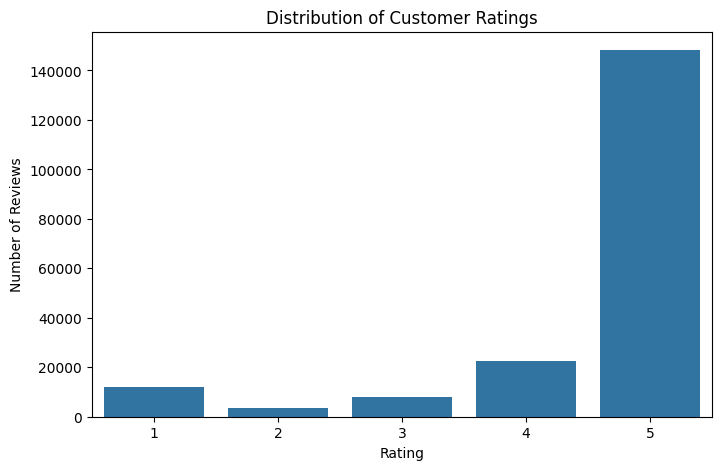

In [72]:
# Rating distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='ratings',
    order=sorted(df['ratings'].unique())
)

plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

plt.show()

In [73]:
# Average customer rating

average_rating = df['ratings'].mean()

print(f"Average Rating: {average_rating:.2f} / 5")

Average Rating: 4.50 / 5


In [74]:
# Check date range

print("Earliest review:", df['review_date'].min())
print("Latest review:", df['review_date'].max())

Earliest review: 2023-07-25 15:01:35
Latest review: 2024-08-23 19:30:05


In [75]:
# Create month column for time-based analysis

df['review_month'] = df['review_date'].dt.to_period('M')

df['review_month'].value_counts().sort_index().head(10)

,count
review_month,
2023-07,8283
2023-08,6801
2023-09,7593
2023-10,5824
2023-11,8719
2023-12,10375
2024-01,9313
2024-02,8748
2024-03,15173


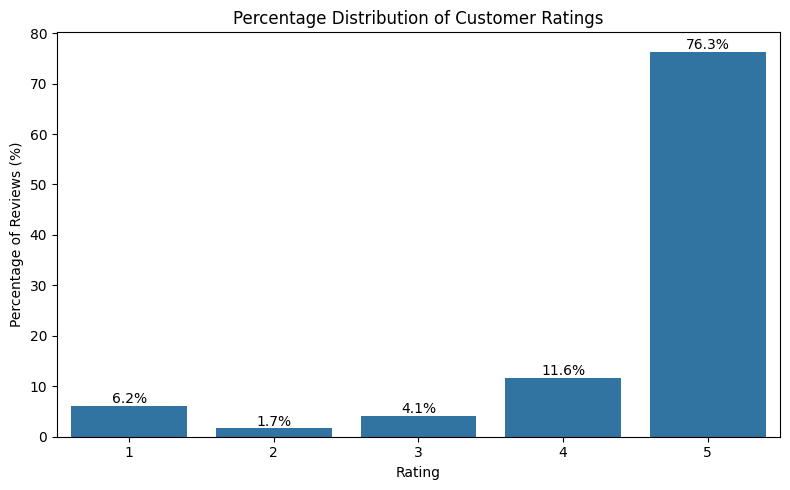

In [76]:
# Rating percentage

rating_percentage = (
    df['ratings']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=rating_percentage.index,
    y=rating_percentage.values
)

plt.title('Percentage Distribution of Customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Percentage of Reviews (%)')

for i, value in enumerate(rating_percentage.values):
    ax.text(i, value + 0.5, f'{value:.1f}%', ha='center')

plt.tight_layout()
plt.show()

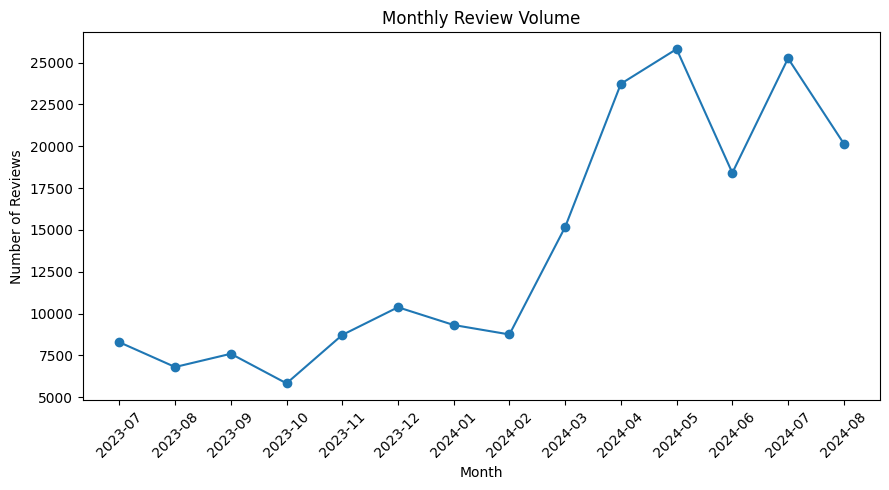

In [77]:
# Monthly review trend

monthly_reviews = (
    df.dropna(subset=['review_date'])
      .groupby(df['review_date'].dt.to_period('M'))
      .size()
)

monthly_reviews.index = monthly_reviews.index.astype(str)

plt.figure(figsize=(9, 5))

plt.plot(
    monthly_reviews.index,
    monthly_reviews.values,
    marker='o'
)

plt.title('Monthly Review Volume')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [78]:
!pip install textblob -q

In [79]:
# Function to calculate polarity and subjectivity

def get_sentiment(text):
    blob = TextBlob(str(text))

    return pd.Series({
        'polarity': blob.sentiment.polarity,
        'subjectivity': blob.sentiment.subjectivity
    })

In [80]:
# Calculate polarity and subjectivity

sentiment_scores = df['review'].apply(get_sentiment)

df[['polarity', 'subjectivity']] = sentiment_scores

df.head()

,review_id,review,ratings,review_date,review_month,polarity,subjectivity
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05,2024-08,0.7000,0.600000
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18,2024-08,0.7000,0.600000
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59,2024-08,0.6000,1.000000
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50,2024-08,0.6000,1.000000
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to anything, it gives me tips, in gaming, studies, and life, etc. This app is also helpful if you were having problems in things! also there are some pr...",5,2024-08-23 19:20:39,2024-08,0.4125,0.542949


In [81]:
# Categorize reviews based on polarity

def classify_sentiment(polarity):
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'


df['sentiment'] = df['polarity'].apply(classify_sentiment)

df['sentiment'].value_counts()

,count
sentiment,
Positive,148219
Neutral,37922
Negative,8069


In [82]:
# Sentiment distribution in percentage

sentiment_percentage = (
    df['sentiment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

sentiment_percentage

,proportion
sentiment,
Positive,76.32
Neutral,19.53
Negative,4.15


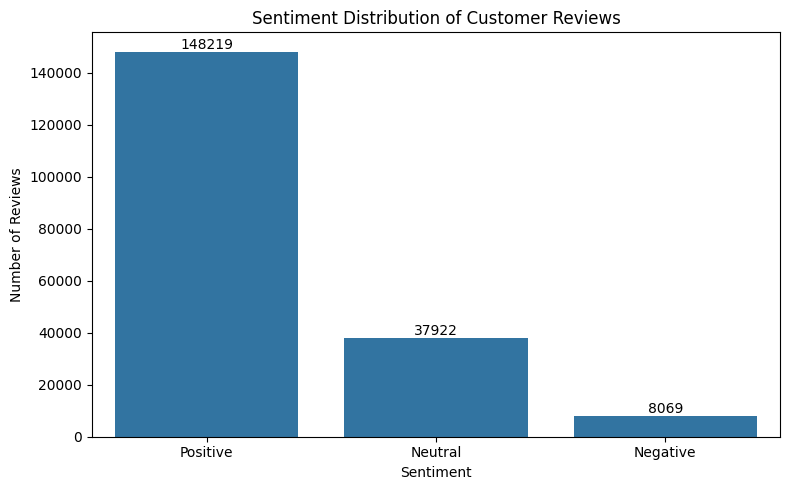

In [83]:
# Sentiment distribution

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x='sentiment',
    order=['Positive', 'Neutral', 'Negative']
)

plt.title('Sentiment Distribution of Customer Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

In [84]:
df['sentiment'].value_counts()

,count
sentiment,
Positive,148219
Neutral,37922
Negative,8069


In [85]:
# Sentiment distribution across ratings

rating_sentiment = pd.crosstab(
    df['ratings'],
    df['sentiment']
)

rating_sentiment

sentiment,Negative,Neutral,Positive
ratings,,,
1,3563,4638,3762
2,707,971,1668
3,822,1911,5313
4,870,3956,17777
5,2107,26446,119699


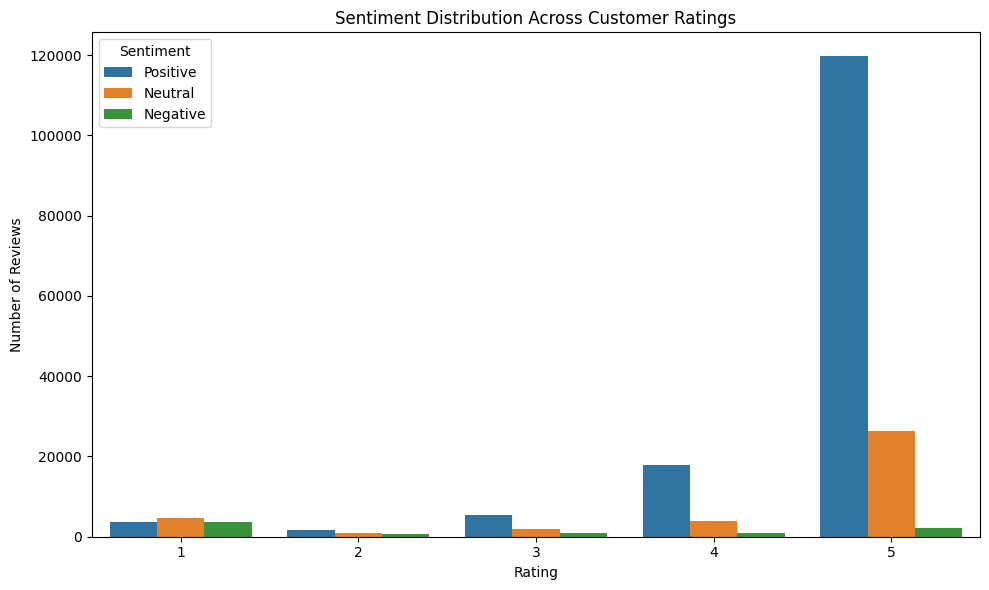

In [86]:
# Rating vs Sentiment

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='ratings',
    hue='sentiment',
    order=sorted(df['ratings'].unique())
)

plt.title('Sentiment Distribution Across Customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.legend(title='Sentiment')

plt.tight_layout()
plt.show()

In [87]:
# Percentage of sentiments within each rating

rating_sentiment_pct = pd.crosstab(
    df['ratings'],
    df['sentiment'],
    normalize='index'
) * 100

rating_sentiment_pct.round(2)

sentiment,Negative,Neutral,Positive
ratings,,,
1,29.78,38.77,31.45
2,21.13,29.02,49.85
3,10.22,23.75,66.03
4,3.85,17.50,78.65
5,1.42,17.84,80.74


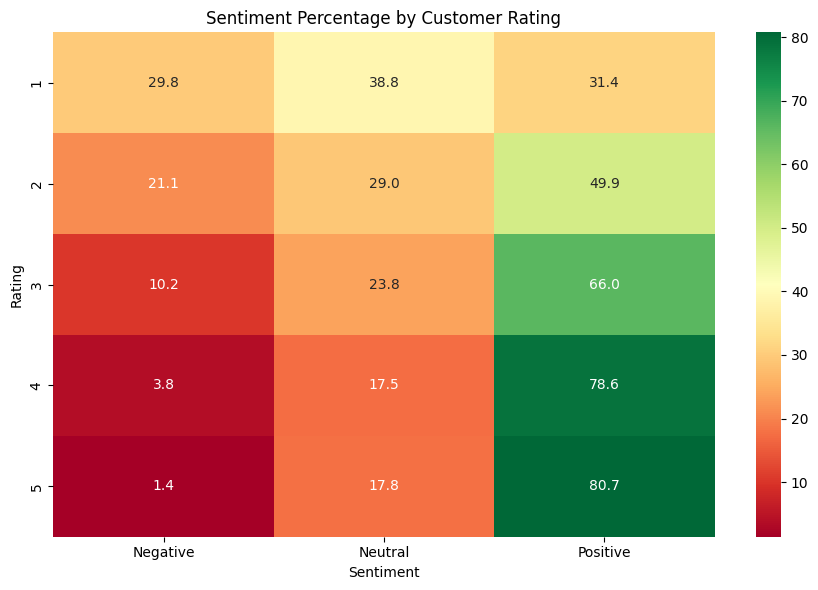

In [88]:
# Heatmap: Rating vs Sentiment percentage

plt.figure(figsize=(9, 6))

sns.heatmap(
    rating_sentiment_pct,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn'
)

plt.title('Sentiment Percentage by Customer Rating')
plt.xlabel('Sentiment')
plt.ylabel('Rating')

plt.tight_layout()
plt.show()

In [89]:
negative_high_rating = df[
    (df['sentiment'] == 'Negative') &
    (df['ratings'] >= 4)
]

print("Negative sentiment + 4/5 star reviews:",
      len(negative_high_rating))

negative_high_rating[['ratings', 'review', 'polarity']].head(10)

Negative sentiment + 4/5 star reviews: 2977


,ratings,review,polarity
229,4,"there are typing bug. if I backspace, previous space get delete too",-0.166667
433,5,Unbelievable 🥰🥰😘😘Nice,-0.250000
467,5,I never tried it yet but at least now,-0.300000
681,5,its fast on non complex tasks but slow on complex tasks. but its ok. i like it😀😀👍👍. i use chatgpt to help me on HTML and CSS code.,-0.040000
812,5,Extreme level response from GPT.,-0.125000
833,4,fascinating in some aspects a little frustrating in others but we're at the model T stage in artificial intelligence. Wait until we start racing these things. It won't be long wait...,-0.107500
885,5,"Most reliable and versatile AI at the moment. Google's AI is surprisingly bad, even worse than Microsoft's.",-0.200000
923,4,"Thank you for existing, this app really helpful but sometimes it gives wrong information so I'm giving 4 star",-0.150000
957,5,single life,-0.071429
1023,5,Awful. I don't know how they managed to make GPT4 so bad in such a short period of time. The latest GPT4 is completely useless and incapable of doing anything complex. A waste of money. Going to c...,-0.275000


In [90]:
positive_low_rating = df[
    (df['sentiment'] == 'Positive') &
    (df['ratings'] <= 2)
]

print("Positive sentiment + 1/2 star reviews:",
      len(positive_low_rating))

positive_low_rating[['ratings', 'review', 'polarity']].head(10)

Positive sentiment + 1/2 star reviews: 5430


,ratings,review,polarity
7,1,great app,0.800000
70,2,"You must 3 add the crop feature to photo, beneficial for people wants to ask questions about the specific part of the photo",0.100000
121,2,good,0.700000
140,1,amazing experience on chatgtp but it's problem on the should be explain in long terms,0.275000
150,2,This app is good but it is not great,0.150000
172,2,This is good app for students but this is not solve my bsc maths problem correctly.,0.700000
217,1,we should need chat gpt plus for free.,0.400000
274,1,good,0.700000
299,1,good,0.700000
328,1,"They have a limit now to talk to the ai? The ""stop generating"" button was removed, it constantly bugs, it often ignores what you said and comes up with the most random response. Often gets things ...",0.014286


In [91]:
# Subjectivity statistics

df['subjectivity'].describe()

,subjectivity
count,194210.000000
mean,0.516702
std,0.339415
min,0.000000
25%,0.300000
50%,0.600000
75%,0.780000
max,1.000000


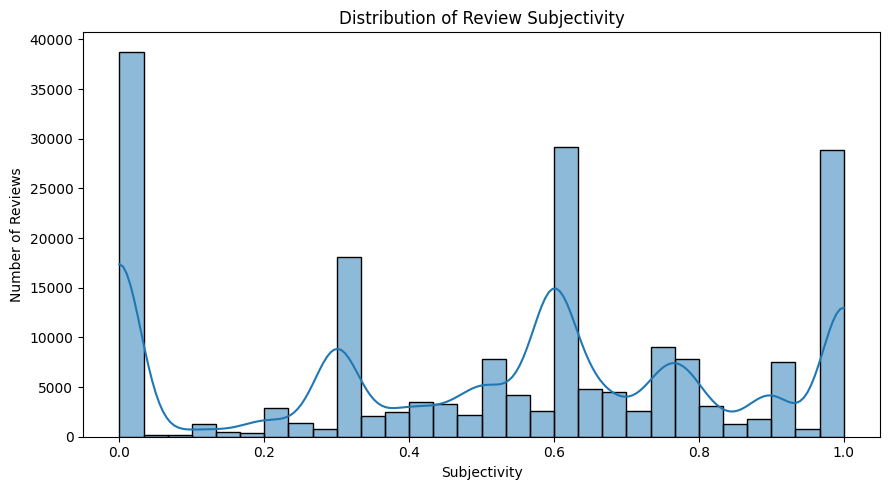

In [92]:
# Subjectivity distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x='subjectivity',
    bins=30,
    kde=True
)

plt.title('Distribution of Review Subjectivity')
plt.xlabel('Subjectivity')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

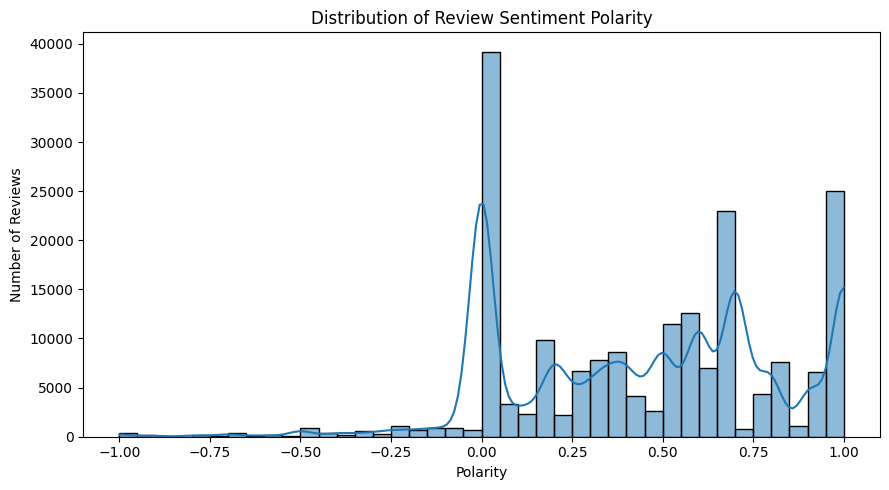

In [93]:
# Polarity distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x='polarity',
    bins=40,
    kde=True
)

plt.title('Distribution of Review Sentiment Polarity')
plt.xlabel('Polarity')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

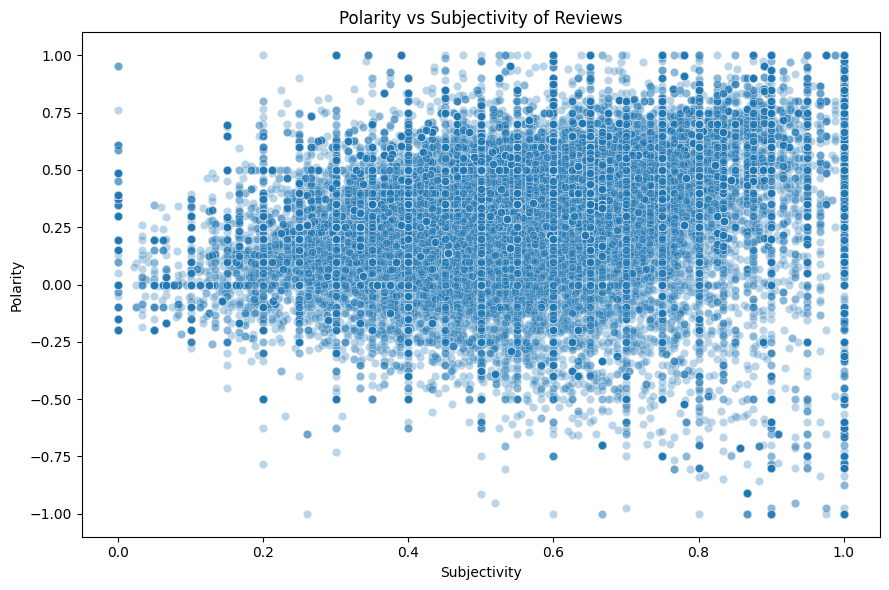

In [94]:
# Polarity vs Subjectivity

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='subjectivity',
    y='polarity',
    alpha=0.3
)

plt.title('Polarity vs Subjectivity of Reviews')
plt.xlabel('Subjectivity')
plt.ylabel('Polarity')

plt.tight_layout()
plt.show()

In [95]:
# Load English stopwords

stop_words = set(stopwords.words('english'))

print("Number of stopwords:", len(stop_words))

Number of stopwords: 198


In [96]:
# Add custom stopwords

custom_stopwords = {
    'chatgpt',
    'app',
    'use',
    'using',
    'used',
    'get',
    'got',
    'one',
    'like',
    'really',
    'also',
    'even',
    'would',
    'could',
    'much',
    'make',
    'made',
    'can',
    'im',
    'ive',
    'dont',
    'didnt'
}

stop_words.update(custom_stopwords)

In [97]:
# Function to clean review text

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Split into words
    words = text.split()

    # Remove stopwords and very short words
    words = [
        word for word in words
        if word not in stop_words and len(word) > 2
    ]

    return words

In [98]:
# Test the cleaning function

sample_review = df['review'].iloc[0]

print("Original review:")
print(sample_review)

print("\nCleaned words:")
print(clean_text(sample_review))

Original review:
good

Cleaned words:
['good']


In [99]:
# Select positive reviews

positive_reviews = df[df['sentiment'] == 'Positive']['review']

print("Number of positive reviews:", len(positive_reviews))

Number of positive reviews: 148219


In [100]:
# Extract words from positive reviews

positive_words = []

for review in positive_reviews:
    positive_words.extend(clean_text(review))

print("Total positive words:", len(positive_words))

Total positive words: 605072


In [101]:
# Most common positive keywords

positive_word_counts = Counter(positive_words)

top_positive_words = positive_word_counts.most_common(20)

top_positive_words

[('good', 38637),
 ('best', 18087),
 ('nice', 13610),
 ('great', 11788),
 ('helpful', 9607),
 ('amazing', 8558),
 ('love', 8524),
 ('useful', 7474),
 ('excellent', 6068),
 ('awesome', 5014),
 ('chat', 4795),
 ('gpt', 4182),
 ('ever', 3835),
 ('information', 3434),
 ('help', 3408),
 ('work', 3344),
 ('better', 3341),
 ('answers', 3040),
 ('answer', 3008),
 ('application', 2950)]

In [102]:
# Convert positive keywords to DataFrame

positive_keywords_df = pd.DataFrame(
    top_positive_words,
    columns=['word', 'frequency']
)

positive_keywords_df

,word,frequency
0,good,38637
1,best,18087
2,nice,13610
3,great,11788
4,helpful,9607
5,amazing,8558
6,love,8524
7,useful,7474
8,excellent,6068
9,awesome,5014


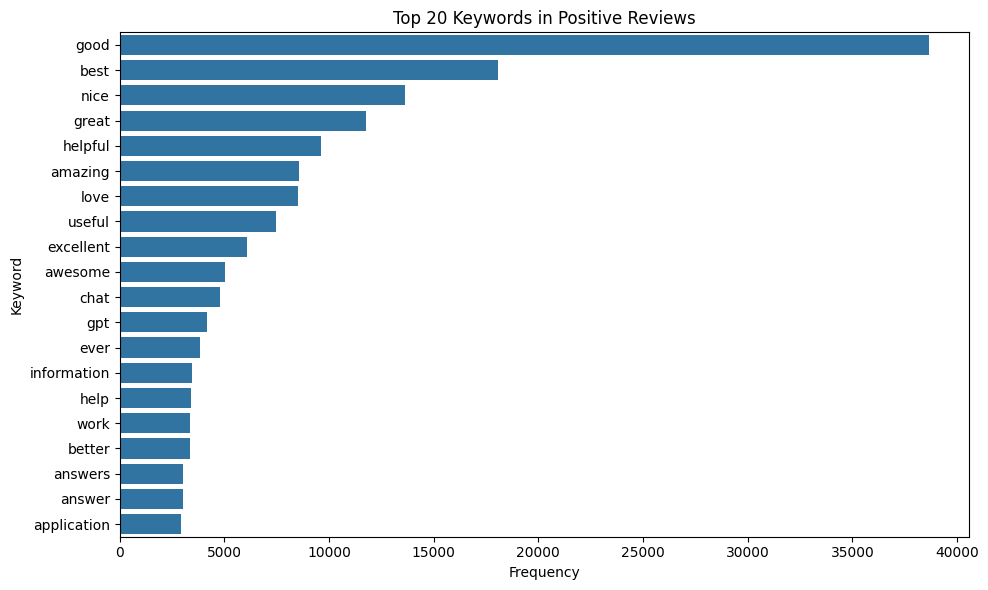

In [103]:
# Top positive keywords

plt.figure(figsize=(10, 6))

sns.barplot(
    data=positive_keywords_df,
    x='frequency',
    y='word'
)

plt.title('Top 20 Keywords in Positive Reviews')
plt.xlabel('Frequency')
plt.ylabel('Keyword')

plt.tight_layout()
plt.show()

In [105]:
# Select negative reviews

negative_reviews = df[df['sentiment'] == 'Negative']['review']

print("Number of negative reviews:", len(negative_reviews))

Number of negative reviews: 8069


In [106]:
# Extract words from negative reviews

negative_words = []

for review in negative_reviews:
    negative_words.extend(clean_text(review))

print("Total negative words:", len(negative_words))

Total negative words: 73280


In [107]:
# Extract words from negative reviews

negative_words = []

for review in negative_reviews:
    negative_words.extend(clean_text(review))

print("Total negative words:", len(negative_words))

Total negative words: 73280


In [108]:
# Most common negative keywords

negative_word_counts = Counter(negative_words)

top_negative_words = negative_word_counts.most_common(20)

top_negative_words

[('wrong', 857),
 ('bad', 852),
 ('time', 615),
 ('answer', 567),
 ('chat', 551),
 ('gpt', 455),
 ('please', 452),
 ('information', 436),
 ('answers', 409),
 ('give', 405),
 ('good', 397),
 ('worst', 359),
 ('work', 349),
 ('voice', 344),
 ('sometimes', 341),
 ('useless', 316),
 ('error', 305),
 ('questions', 303),
 ('google', 292),
 ('version', 282)]

In [109]:
# Convert negative keywords to DataFrame

negative_keywords_df = pd.DataFrame(
    top_negative_words,
    columns=['word', 'frequency']
)

negative_keywords_df

,word,frequency
0,wrong,857
1,bad,852
2,time,615
3,answer,567
4,chat,551
5,gpt,455
6,please,452
7,information,436
8,answers,409
9,give,405


In [110]:
# Convert negative keywords to DataFrame

negative_keywords_df = pd.DataFrame(
    top_negative_words,
    columns=['word', 'frequency']
)

negative_keywords_df

,word,frequency
0,wrong,857
1,bad,852
2,time,615
3,answer,567
4,chat,551
5,gpt,455
6,please,452
7,information,436
8,answers,409
9,give,405


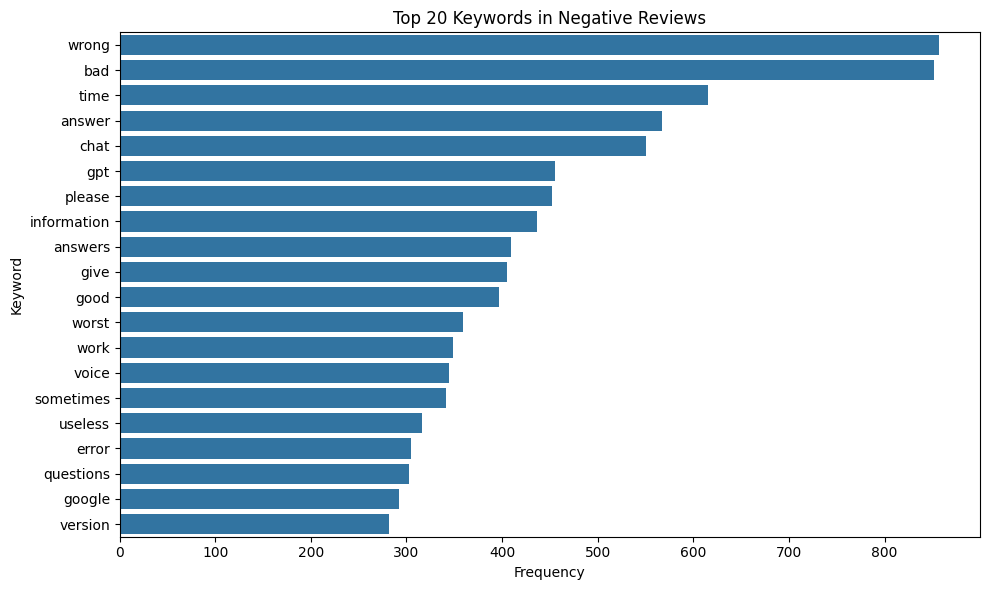

In [111]:
# Top negative keywords

plt.figure(figsize=(10, 6))

sns.barplot(
    data=negative_keywords_df,
    x='frequency',
    y='word'
)

plt.title('Top 20 Keywords in Negative Reviews')
plt.xlabel('Frequency')
plt.ylabel('Keyword')

plt.tight_layout()
plt.show()

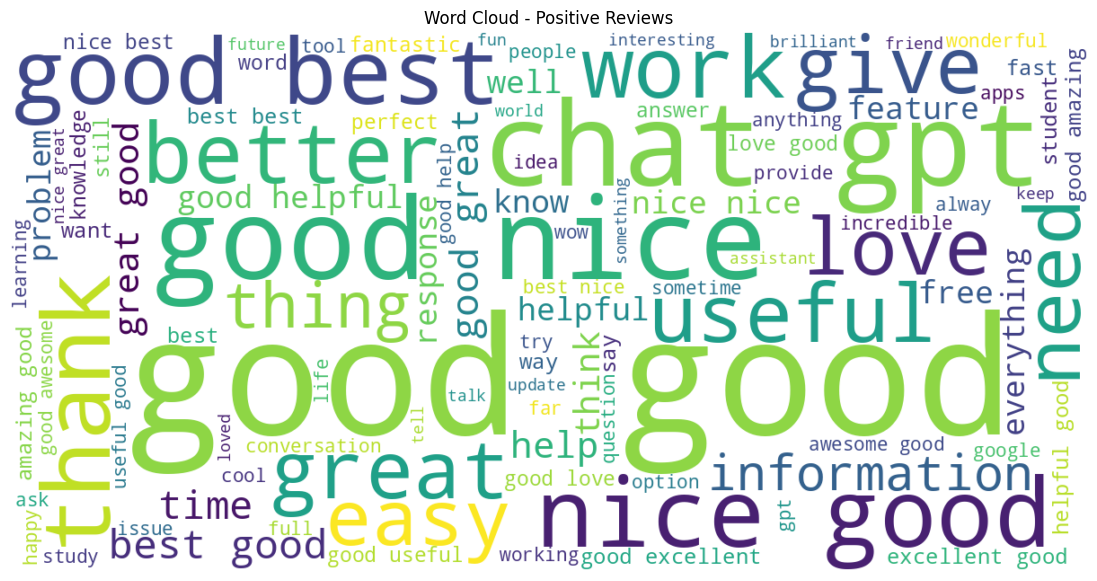

In [112]:
# Positive review word cloud

positive_text = ' '.join(positive_words)

positive_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100
).generate(positive_text)

plt.figure(figsize=(14, 7))
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Reviews')

plt.show()

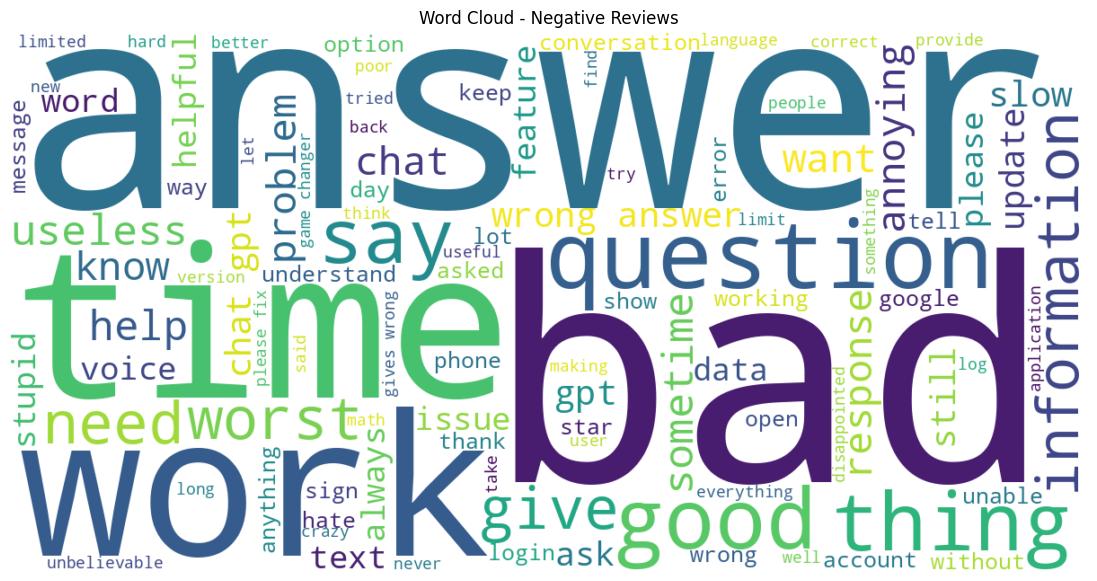

In [113]:
# Negative review word cloud

negative_text = ' '.join(negative_words)

negative_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100
).generate(negative_text)

plt.figure(figsize=(14, 7))
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Negative Reviews')

plt.show()

In [115]:
from sklearn.feature_extraction.text import CountVectorizer

In [116]:
# Separate positive and negative reviews

positive_text_data = df.loc[
    df['sentiment'] == 'Positive', 'review'
].astype(str)

negative_text_data = df.loc[
    df['sentiment'] == 'Negative', 'review'
].astype(str)

print("Positive reviews:", len(positive_text_data))
print("Negative reviews:", len(negative_text_data))

Positive reviews: 148219
Negative reviews: 8069


In [117]:
# Extract 2-word and 3-word phrases from positive reviews

vectorizer_positive = CountVectorizer(
    stop_words='english',
    ngram_range=(2, 3),
    min_df=20
)

positive_matrix = vectorizer_positive.fit_transform(
    positive_text_data
)

positive_phrase_counts = pd.DataFrame({
    'phrase': vectorizer_positive.get_feature_names_out(),
    'frequency': positive_matrix.sum(axis=0).A1
}).sort_values(
    'frequency',
    ascending=False
).reset_index(drop=True)

positive_phrase_counts.head(20)

,phrase,frequency
0,good app,5804
1,best app,4822
2,nice app,3292
3,great app,3083
4,chat gpt,2657
5,best ai,2462
6,love app,1850
7,amazing app,1534
8,useful app,1205
9,really good,1177


In [118]:
# Extract 2-word and 3-word phrases from negative reviews

vectorizer_negative = CountVectorizer(
    stop_words='english',
    ngram_range=(2, 3),
    min_df=5
)

negative_matrix = vectorizer_negative.fit_transform(
    negative_text_data
)

negative_phrase_counts = pd.DataFrame({
    'phrase': vectorizer_negative.get_feature_names_out(),
    'frequency': negative_matrix.sum(axis=0).A1
}).sort_values(
    'frequency',
    ascending=False
).reset_index(drop=True)

negative_phrase_counts.head(20)

,phrase,frequency
0,chat gpt,225
1,worst app,133
2,wrong answer,123
3,bad app,120
4,gives wrong,112
5,wrong answers,110
6,game changer,105
7,doesn work,96
8,wrong information,92
9,don know,85


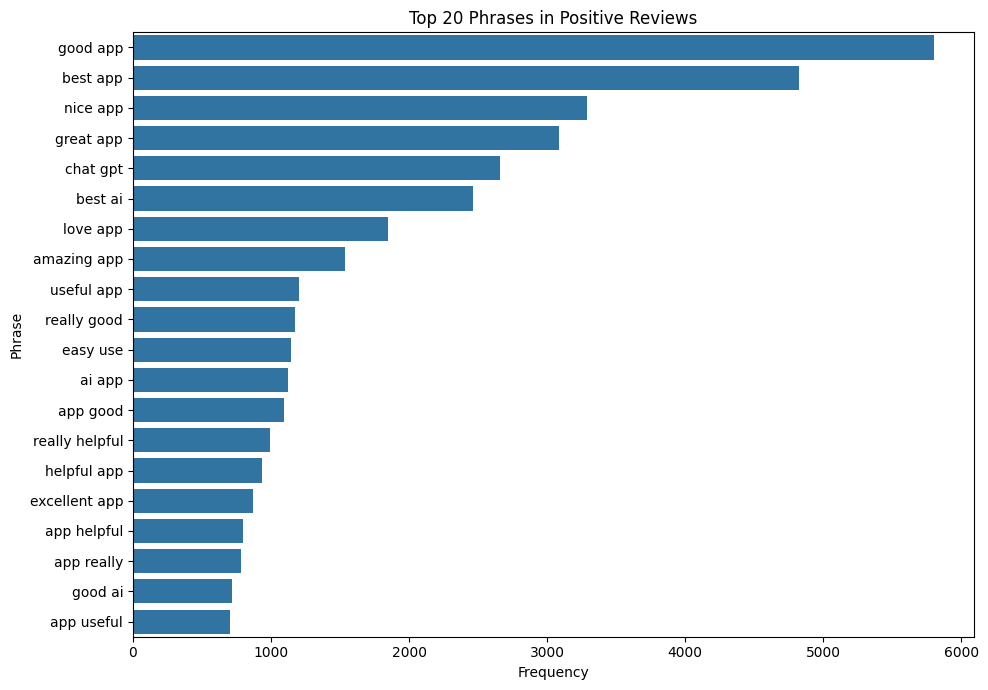

In [119]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=positive_phrase_counts.head(20),
    x='frequency',
    y='phrase'
)

plt.title('Top 20 Phrases in Positive Reviews')
plt.xlabel('Frequency')
plt.ylabel('Phrase')

plt.tight_layout()
plt.show()

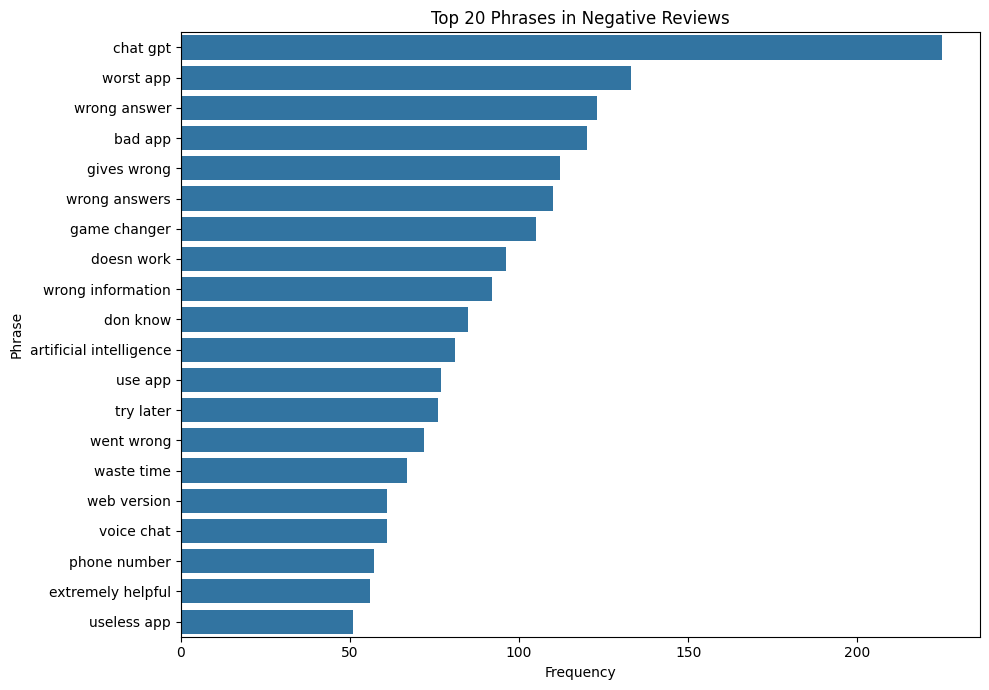

In [120]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=negative_phrase_counts.head(20),
    x='frequency',
    y='phrase'
)

plt.title('Top 20 Phrases in Negative Reviews')
plt.xlabel('Frequency')
plt.ylabel('Phrase')

plt.tight_layout()
plt.show()

In [121]:
# Display top positive phrases

positive_phrase_counts.head(20)

,phrase,frequency
0,good app,5804
1,best app,4822
2,nice app,3292
3,great app,3083
4,chat gpt,2657
5,best ai,2462
6,love app,1850
7,amazing app,1534
8,useful app,1205
9,really good,1177


In [122]:
# Display top negative phrases

negative_phrase_counts.head(20)

,phrase,frequency
0,chat gpt,225
1,worst app,133
2,wrong answer,123
3,bad app,120
4,gives wrong,112
5,wrong answers,110
6,game changer,105
7,doesn work,96
8,wrong information,92
9,don know,85


In [123]:
# Define customer feedback themes

positive_themes = {
    'Overall Satisfaction': r'\bgood app\b|\bbest app\b|\bnice app\b|\bgreat app\b|\bamazing app\b|\bexcellent app\b',
    'Helpfulness': r'\breally helpful\b|\bhelpful app\b',
    'Usefulness': r'\buseful app\b|\bapp useful\b',
    'Ease of Use': r'\beasy use\b',
    'AI Capability': r'\bbest ai\b|\bgood ai\b'
}

negative_themes = {
    'Accuracy & Answer Quality': r'\bwrong answer\b|\bwrong answers\b|\bgives wrong\b|\bwrong information\b',
    'Functionality': r'\bdoesn t work\b|\bbad app\b|\bworst app\b|\buseless app\b',
    'Performance': r'\bwaste time\b',
    'Voice Feature': r'\bvoice chat\b'
}

In [124]:
# Count positive themes

positive_theme_results = {}

for theme, pattern in positive_themes.items():
    count = df[
        df['review'].str.lower().str.contains(
            pattern,
            regex=True,
            na=False
        )
    ].shape[0]

    positive_theme_results[theme] = count

positive_theme_results

{'Overall Satisfaction': 18677,
 'Helpfulness': 1899,
 'Usefulness': 1173,
 'Ease of Use': 14,
 'AI Capability': 3054}

In [125]:
# Count negative themes

negative_theme_results = {}

for theme, pattern in negative_themes.items():
    count = df[
        df['review'].str.lower().str.contains(
            pattern,
            regex=True,
            na=False
        )
    ].shape[0]

    negative_theme_results[theme] = count

negative_theme_results

{'Accuracy & Answer Quality': 527,
 'Functionality': 308,
 'Performance': 13,
 'Voice Feature': 477}

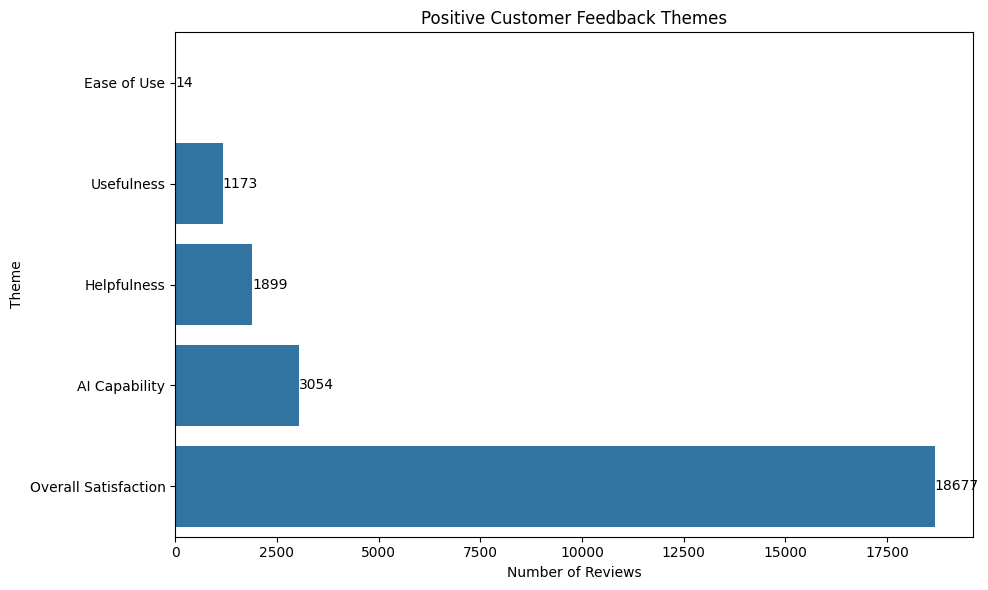

In [126]:
positive_theme_df = pd.DataFrame(
    list(positive_theme_results.items()),
    columns=['Theme', 'Review Count']
).sort_values(
    'Review Count',
    ascending=True
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=positive_theme_df,
    x='Review Count',
    y='Theme'
)

plt.title('Positive Customer Feedback Themes')
plt.xlabel('Number of Reviews')
plt.ylabel('Theme')

for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

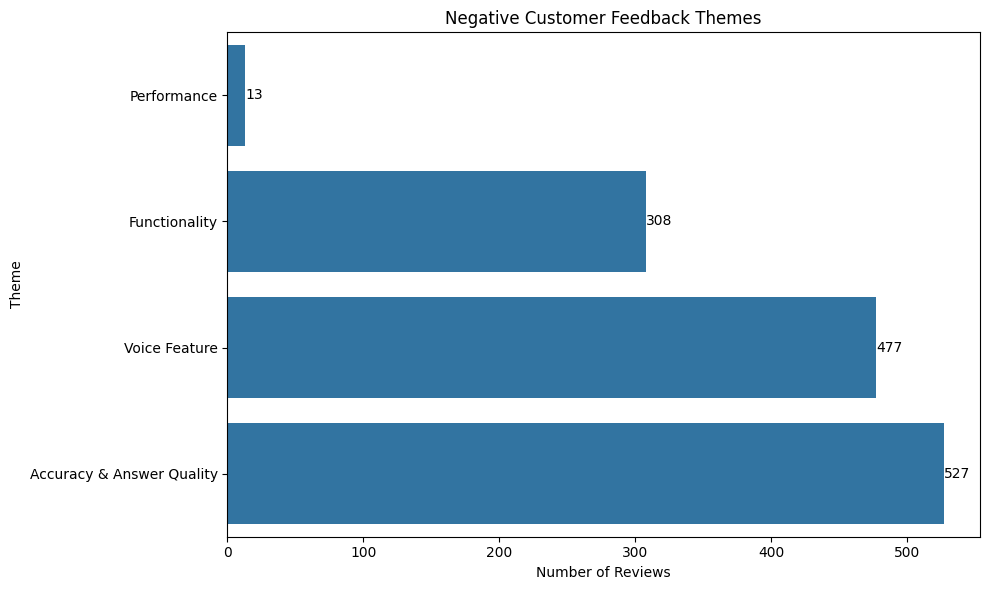

In [127]:
negative_theme_df = pd.DataFrame(
    list(negative_theme_results.items()),
    columns=['Theme', 'Review Count']
).sort_values(
    'Review Count',
    ascending=True
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=negative_theme_df,
    x='Review Count',
    y='Theme'
)

plt.title('Negative Customer Feedback Themes')
plt.xlabel('Number of Reviews')
plt.ylabel('Theme')

for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

In [128]:
# Sentiment summary

sentiment_summary = (
    df['sentiment']
    .value_counts()
    .rename_axis('Sentiment')
    .reset_index(name='Review Count')
)

sentiment_summary['Percentage'] = (
    sentiment_summary['Review Count']
    / len(df) * 100
).round(2)

sentiment_summary

,Sentiment,Review Count,Percentage
0,Positive,148219,76.32
1,Neutral,37922,19.53
2,Negative,8069,4.15


In [129]:
# Average rating by sentiment

avg_rating_sentiment = (
    df.groupby('sentiment')['ratings']
      .agg(['count', 'mean'])
      .round(2)
      .sort_values('mean', ascending=False)
)

avg_rating_sentiment

,count,mean
sentiment,,
Positive,148219,4.67
Neutral,37922,4.23
Negative,8069,2.66


In [130]:
# Average sentiment polarity for each rating

rating_polarity = (
    df.groupby('ratings')['polarity']
      .agg(['count', 'mean'])
      .round(3)
)

rating_polarity

,count,mean
ratings,,
1,11963,0.013
2,3346,0.158
3,8046,0.304
4,22603,0.425
5,148252,0.499


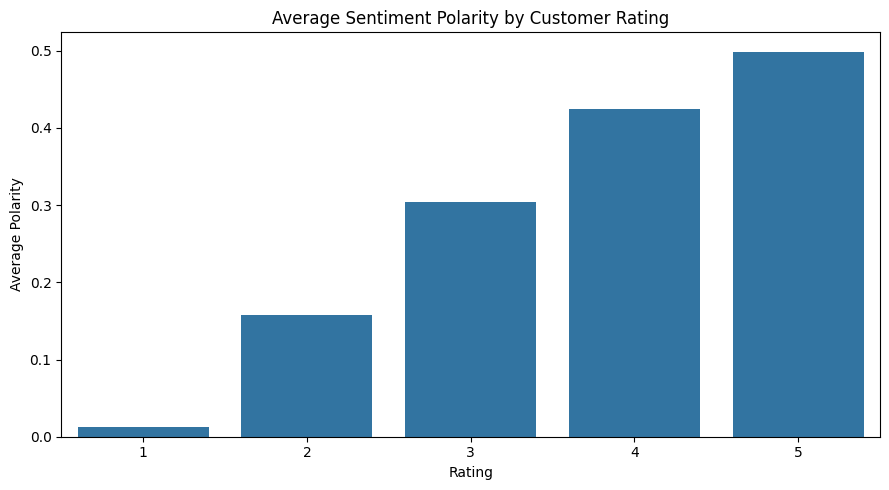

In [131]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=rating_polarity.reset_index(),
    x='ratings',
    y='mean'
)

plt.title('Average Sentiment Polarity by Customer Rating')
plt.xlabel('Rating')
plt.ylabel('Average Polarity')

plt.tight_layout()
plt.show()

In [132]:
# Monthly sentiment distribution

monthly_sentiment = (
    df.dropna(subset=['review_date'])
      .groupby([
          df['review_date'].dt.to_period('M'),
          'sentiment'
      ])
      .size()
      .unstack(fill_value=0)
)

monthly_sentiment

sentiment,Negative,Neutral,Positive
review_date,,,
2023-07,480,1809,5994
2023-08,440,1439,4922
2023-09,389,1433,5771
2023-10,247,1169,4408
2023-11,394,1667,6658
2023-12,461,2048,7866
2024-01,457,1952,6904
2024-02,459,1716,6573
2024-03,659,3020,11494


In [133]:
# Monthly sentiment percentage

monthly_sentiment_pct = (
    monthly_sentiment
    .div(monthly_sentiment.sum(axis=1), axis=0)
    * 100
).round(2)

monthly_sentiment_pct

sentiment,Negative,Neutral,Positive
review_date,,,
2023-07,5.80,21.84,72.37
2023-08,6.47,21.16,72.37
2023-09,5.12,18.87,76.00
2023-10,4.24,20.07,75.69
2023-11,4.52,19.12,76.36
2023-12,4.44,19.74,75.82
2024-01,4.91,20.96,74.13
2024-02,5.25,19.62,75.14
2024-03,4.34,19.90,75.75


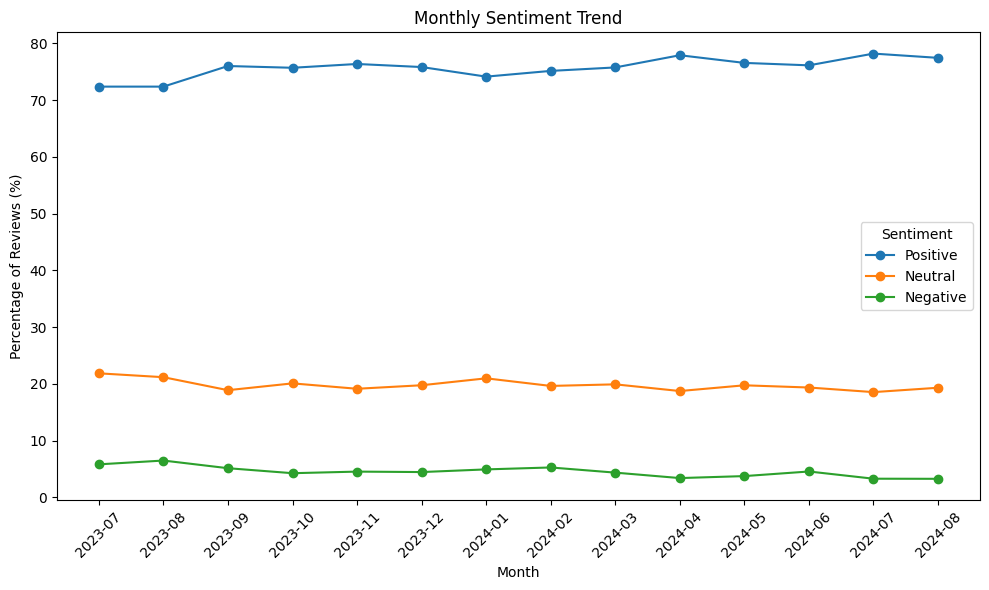

In [134]:
plt.figure(figsize=(10, 6))

for sentiment in ['Positive', 'Neutral', 'Negative']:
    if sentiment in monthly_sentiment_pct.columns:
        plt.plot(
            monthly_sentiment_pct.index.astype(str),
            monthly_sentiment_pct[sentiment],
            marker='o',
            label=sentiment
        )

plt.title('Monthly Sentiment Trend')
plt.xlabel('Month')
plt.ylabel('Percentage of Reviews (%)')
plt.legend(title='Sentiment')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [135]:
# Final project metrics

print("========== PROJECT SUMMARY ==========")

print(f"Total Reviews: {len(df):,}")
print(f"Average Rating: {df['ratings'].mean():.2f}/5")

print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

print("\nAverage Polarity:")
print(f"{df['polarity'].mean():.3f}")

print("\nAverage Subjectivity:")
print(f"{df['subjectivity'].mean():.3f}")

print("\nRating Distribution:")
print(df['ratings'].value_counts().sort_index())

========== PROJECT SUMMARY ==========
Total Reviews: 194,210
Average Rating: 4.50/5

Sentiment Distribution:
sentiment
Positive    148219
Neutral      37922
Negative      8069
Name: count, dtype: int64

Average Polarity:
0.447

Average Subjectivity:
0.517

Rating Distribution:
ratings
1     11963
2      3346
3      8046
4     22603
5    148252
Name: count, dtype: int64


In [136]:
# Check current dataset size and duplicate rows

print("Current dataset shape:", df.shape)
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate Review IDs:", df['review_id'].duplicated().sum())

Current dataset shape: (194210, 8)
Exact duplicate rows: 0
Duplicate Review IDs: 1062


In [137]:
# Check how many reviews exist for each sentiment

print(df['sentiment'].value_counts())

print("\nTotal sentiment records:",
      df['sentiment'].notna().sum())

sentiment
Positive    148219
Neutral      37922
Negative      8069
Name: count, dtype: int64

Total sentiment records: 194210


In [138]:
# Check rating totals

print(df['ratings'].value_counts().sort_index())

print("\nTotal rating records:",
      df['ratings'].notna().sum())

ratings
1     11963
2      3346
3      8046
4     22603
5    148252
Name: count, dtype: int64

Total rating records: 194210


In [139]:
# Check the date range and missing values

print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDate range:")
print("Earliest:", df['review_date'].min())
print("Latest:", df['review_date'].max())

Shape: (194210, 8)

Missing values:
review_id       0
review          0
ratings         0
review_date     0
review_month    0
polarity        0
subjectivity    0
sentiment       0
dtype: int64

Date range:
Earliest: 2023-07-25 15:01:35
Latest: 2024-08-23 19:30:05


In [140]:
# Check Review ID duplication

duplicate_ids = df[df['review_id'].duplicated(keep=False)]

print("Rows with duplicated Review IDs:", len(duplicate_ids))
print("Unique duplicated Review IDs:", duplicate_ids['review_id'].nunique())

duplicate_ids.head(20)

Rows with duplicated Review IDs: 2000
Unique duplicated Review IDs: 938


,review_id,review,ratings,review_date,review_month,polarity,subjectivity,sentiment
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to anything, it gives me tips, in gaming, studies, and life, etc. This app is also helpful if you were having problems in things! also there are some pr...",5,2024-08-23 19:20:39,2024-08,0.412500,0.542949,Positive
10,17769ae4-51f6-439c-af12-f59d242e1f6b,I am not very happy with this because chatgpt answers the questions I ask but it stops midway. Then even after continuous efforts it does not give complete answer. This is not very correct.Please ...,3,2024-08-23 19:09:14,2024-08,-0.172527,0.495604,Negative
25,83eae4a4-4ae8-42e4-975d-73f385586900,2024-08-23 Call function doesn't get language correctly and sometimes translates prompts or answer in different languages.,2,2024-08-23 18:38:45,2024-08,0.000000,0.600000,Neutral
194,8fd2ff52-7294-4a1d-874a-163d5e08dcfa,"Good job!!!, Chat GPT.",3,2024-08-23 15:32:33,2024-08,1.000000,0.600000,Positive
289,e0451ef0-7d81-44c8-9c92-a4ec88178461,Best Ai app. It would be better if they give 4o version access for free.,5,2024-08-23 14:22:34,2024-08,0.633333,0.533333,Positive
333,80de7242-a387-4dec-9e74-7f22fd7998e4,Edit 08/23/2024: Why can't we hit a STOP ⏹️ button anymore when the AI has gone off on a tangent and isn't appropriate answering our promot or question? Please reinstate that feature! Please fix i...,2,2024-08-23 13:44:22,2024-08,0.133681,0.311111,Positive
493,53392ed2-e81f-448f-853d-7057ab23e30d,Great,5,2024-08-23 10:57:37,2024-08,0.800000,0.750000,Positive
518,1ece904e-2a2d-4ced-b819-d08239dd24ac,"For me ,it's so useful.what ever u ask ,it will istantly answer. I personally loved it 💖. If u don't like paying apps to use them like me then this free version of chatGPT is ofc for u 🌟.but if ur...",5,2024-08-23 10:29:07,2024-08,0.324045,0.612500,Positive
521,154f0315-2912-48e2-84e8-dc6ae5290b12,Great ai,5,2024-08-23 10:25:16,2024-08,0.800000,0.750000,Positive
709,02229a18-6bb2-40c4-8302-b0c430505f65,"Chat gpt is not allowing me to login in website please fix it. For others, it works.😡I don't care about this app they are not helping their customers. Stop being online when I need help, and then ...",1,2024-08-23 06:55:01,2024-08,0.000000,1.000000,Neutral


In [141]:
# Final data quality check

print("========== DATA QUALITY SUMMARY ==========")

print(f"Total Rows: {len(df):,}")
print(f"Total Columns: {df.shape[1]}")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nExact Duplicate Rows:", df.duplicated().sum())

print("\nDuplicate Review IDs:",
      df['review_id'].duplicated().sum())

print("\nDate Range:")
print("From:", df['review_date'].min())
print("To:", df['review_date'].max())

========== DATA QUALITY SUMMARY ==========
Total Rows: 194,210
Total Columns: 8

Missing Values:
review_id       0
review          0
ratings         0
review_date     0
review_month    0
polarity        0
subjectivity    0
sentiment       0
dtype: int64

Exact Duplicate Rows: 0

Duplicate Review IDs: 1062

Date Range:
From: 2023-07-25 15:01:35
To: 2024-08-23 19:30:05
